### MaliGNNoma-style GIN with Sum READOUT and Graph-Context Fusion

MaliGNNoma is a GNN-based malicious circuit classifier for secure cloud FPGAs. It parses post-synthesis Verilog netlists into data-flow graphs (DFGs), assigns one-hot node-type features, and trains a graph classifier to distinguish benign and malicious FPGA configurations. The original MaliGNNoma framework evaluates GCN and GIN backbones, together with graph pooling and READOUT functions. The reported best MaliGNNoma configuration uses a 2-layer Graph Isomorphism Network (GIN) with hidden dimension 100 and dropout 0.5. For GIN, the default setup uses Sum READOUT without a pooling layer.

In this experiment, we adapt the MaliGNNoma GIN principle to node-level circuit fault detection using `nodes_enhanced.csv` and `edges_enhanced.csv`. Since our task is not graph-level malicious/benign classification, the graph-level Sum READOUT embedding is broadcast back to each node and fused with the node embedding. The resulting model predicts each node as `clean`, `bridging`, `glitch`, or `stuck_at`. This preserves the MaliGNNoma-style GIN design while making it compatible with the fault-localization setting.

Reference BibTeX:

@inproceedings{alrahis2024malignnoma,
  title={MaliGNNoma: GNN-based malicious circuit classifier for secure cloud FPGAs},
  author={Alrahis, Lilas and Nassar, Hassan and Krautter, Jonas and Gnad, Dennis and Bauer, Lars and Henkel, J{\"o}rg and Tahoori, Mehdi},
  booktitle={2024 IEEE International Symposium on Hardware Oriented Security and Trust (HOST)},
  pages={383--393},
  year={2024},
  organization={IEEE}
}

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train and Test overlap: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 18

Test graph netlists and node counts:
------------------------------------
01. sqrt.v | nodes=37097
02. cavlc.v | nodes=1541
03

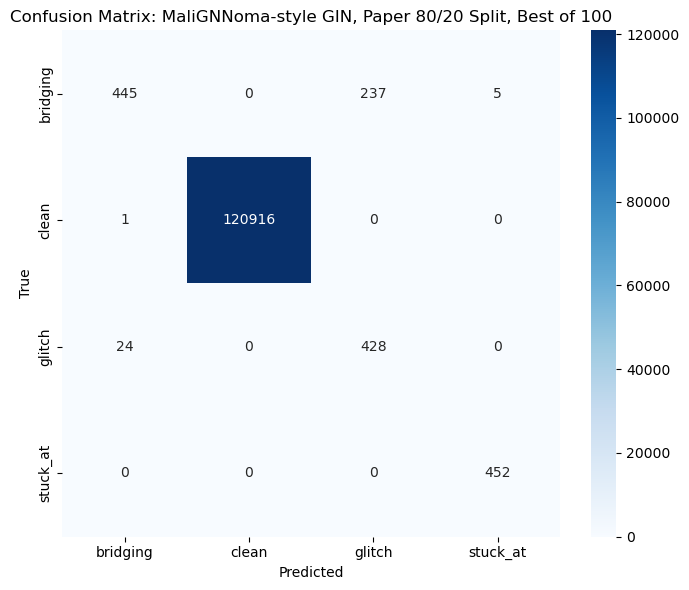


Saved checkpoint to: malignnoma_style_gin_paper_protocol_80_20_100epochs.pt


In [3]:
# ============================================================
# Paper-protocol MaliGNNoma-style GIN with Sum READOUT
# and Graph-Context Fusion
# for Circuit Fault Detection from Enhanced CSVs
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# Task:
#   Node-level 4-class classification:
#   clean, bridging, glitch, stuck_at
#
# Paper-protocol refinement:
#   - 80/20 train/test split by netlist_file
#   - no separate validation split
#   - train for 100 epochs
#   - learning rate = 7e-4
#   - dropout = 0.4
#   - hidden dimension = 64
#   - paper-style class weights
#   - train-only normalization
#   - best model selected by lowest monitored test loss,
#     matching the style of the original paper-code scripts
#   - test netlist names are printed explicitly
#
# Architecture:
#   MaliGNNoma-inspired GIN setup:
#       - 2 GIN layers
#       - Sum READOUT over node embeddings
#       - graph-context embedding broadcast back to nodes
#       - node-level classifier
#
# Note:
#   MaliGNNoma reports hidden_dim=100, dropout=0.5, and lr=0.001.
#   For fair comparison with the paper experiments, this refined version
#   uses hidden_dim=64, dropout=0.4, and lr=7e-4, while keeping the
#   MaliGNNoma-style 2-layer GIN + Sum READOUT design.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GINConv, global_add_pool
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required. Install a PyG version compatible "
        "with your PyTorch/CUDA setup before running this notebook."
    ) from e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# File paths
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# Paper-code behavior:
# prefer clean topology if available; otherwise fall back to union.
EDGE_MODE = "clean"       # choices: "clean", "union"


# -------------------------
# Paper-style training hyperparameters
# -------------------------
EPOCHS = 100
LR = 7e-4
WEIGHT_DECAY = 5e-4

HID = 64
DROPOUT = 0.4


# -------------------------
# MaliGNNoma-style architecture settings
# -------------------------
NUM_GIN_LAYERS = 2


# -------------------------
# Training settings
# -------------------------
BATCH_SIZE = 1

MAX_FAULT_NODES_PER_CLASS_PER_GRAPH = 512
CLEAN_TO_FAULT_RATIO = 1.0

PRINT_EVERY = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "in_degree", "out_degree", "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact", "dist_to_PO",
    "fanout", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node"
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


# -------------------------
# String cleanup
# -------------------------
for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


# -------------------------
# Numeric cleanup
# -------------------------
base_num_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Encode class labels and gate types
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError("Expected a 'clean' class in fault_type.")

clean_idx = class_to_idx["clean"]

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)


def canonical_gate_type(gate_type: str) -> str:
    """
    Paper-compatible compact gate vocabulary.

    Pseudo-fault gate names are mapped to 'other' to reduce direct leakage
    from names such as sa0, sa1, bridge, and glitch.
    """
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 netlist-level train/test split
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test split."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)


train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train and Test overlap:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# Compatibility placeholders in case another helper cell expects val_nets/val_graphs.
# This notebook intentionally follows the paper's train/test-only protocol.
val_nets = np.array([], dtype=object)
val_graphs = []


# ============================================================
# 5. Build one joint graph per netlist
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    """
    Return edges for one netlist.

    EDGE_MODE='clean':
        Use clean topology if available. This mirrors the original
        paper-code style. Fall back to union if clean topology is unavailable.

    EDGE_MODE='union':
        Use all clean + faulted topology edges, deduplicated.
    """
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    use_e = (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )

    return use_e


def build_joint_graphs(nets: np.ndarray) -> List[Data]:
    """
    Build one node-classification graph per netlist.

    Node set:
        Union of clean and faulted nodes.

    Labels:
        Start every node as clean.
        Any non-clean row with label==1 gets the corresponding fault_type class.

    Features:
        Gate one-hot + enhanced numeric features.
        For normal nodes, prefer clean features.
        For pseudo-fault nodes, use the fault row where label==1.
    """
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()

        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0

            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        e_use = select_edges_for_netlist(nf)

        src_list, dst_list = [], []

        if not e_use.empty:
            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s in id2idx and d in id2idx:
                    src_list.append(id2idx[s])
                    dst_list.append(id2idx[d])

        if len(src_list) > 0:
            edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.netlist_file = nf
        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))


print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 6. Append relational features
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    """
    Count unique nodes reachable within <=K hops for every node.
    """
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt

            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt

        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def append_relational_features(data: Data) -> Data:
    """
    Append relational features computed from the original directed circuit graph.
    """
    x = data.x.clone().float()
    N = x.size(0)

    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)

    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_features(graph_list[i])

print("Input dimension after relational features:", train_graphs[0].x.size(1))


# ============================================================
# 7. Add reverse edges for bidirectional context
# ============================================================

def add_reverse_edges(graphs: List[Data]) -> List[Data]:
    """
    GIN itself does not use edge attributes. Reverse edges are added so that
    each node can aggregate both fan-in and fan-out context.
    """
    for g in graphs:
        if g.edge_index.numel() == 0:
            continue

        ei = g.edge_index
        rev_ei = ei.flip(0)
        g.edge_index = torch.cat([ei, rev_ei], dim=1)

    return graphs


train_graphs = add_reverse_edges(train_graphs)
test_graphs = add_reverse_edges(test_graphs)


# ============================================================
# 8. Normalize node features using train split only
# ============================================================

def fit_node_normalizer(graphs: List[Data]):
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)

print("Final node input dimension:", train_graphs[0].x.size(1))


# ============================================================
# 9. Print model-level class distributions
# ============================================================

def labels_from_graphs(graphs: List[Data]) -> np.ndarray:
    return np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)


train_labels_all = labels_from_graphs(train_graphs)
test_labels_all = labels_from_graphs(test_graphs)


def print_final_counts(split_name: str, labels: np.ndarray):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{split_name} final joint-graph class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_final_counts("Train", train_labels_all)
print_final_counts("Test", test_labels_all)


# ============================================================
# 10. Paper-style class weights
# ============================================================

cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)

weights_np = cls_counts.max() / (cls_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)

print("\nClass weights:", class_weights.detach().cpu().numpy())


# ============================================================
# 11. MaliGNNoma-style GIN model
# ============================================================

class MaliGNNomaGINMLP(nn.Module):
    """
    MLP inside GIN update.
    """
    def __init__(self, hidden_dim: int, dropout: float = 0.4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x):
        return self.net(x)


class MaliGNNomaStyleGIN(nn.Module):
    """
    MaliGNNoma-style GIN adapted from graph classification to node classification.

    Original MaliGNNoma best setup:
      - GIN
      - 2 layers
      - Sum READOUT

    Paper-protocol adaptation:
      - node-level fault classification
      - hidden_dim=64 and dropout=0.4 for consistent comparison
      - layer-wise Sum READOUT is projected into graph context
      - graph context is broadcast back to nodes
      - node embedding and graph context are fused for final classification
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        num_layers: int = 2,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)
        self.num_layers = int(num_layers)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = MaliGNNomaGINMLP(hidden_dim, dropout=dropout)
            self.convs.append(
                GINConv(
                    nn=mlp,
                    eps=0.0,
                    train_eps=True,
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))

        # Layer-wise node fusion.
        self.node_jk_proj = nn.Sequential(
            nn.Linear(hidden_dim * (num_layers + 1), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.node_jk_norm = nn.LayerNorm(hidden_dim)

        # MaliGNNoma-style graph Sum READOUT over every GIN layer.
        self.graph_readout_proj = nn.Sequential(
            nn.Linear(hidden_dim * (num_layers + 1), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.graph_readout_norm = nn.LayerNorm(hidden_dim)

        # Fuse graph-level context back into node prediction.
        self.node_graph_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.fusion_norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index

        h = self.input_proj(x)
        h = self.input_norm(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        node_states = [h]

        for conv, norm in zip(self.convs, self.norms):
            if edge_index.numel() == 0:
                h_msg = h
            else:
                h_msg = conv(h, edge_index)

            h = norm(h + F.dropout(h_msg, p=self.dropout_p, training=self.training))
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_p, training=self.training)

            node_states.append(h)

        # Node-level layer fusion.
        h_node_cat = torch.cat(node_states, dim=-1)
        h_node = self.node_jk_proj(h_node_cat)
        h_node = self.node_jk_norm(node_states[-1] + h_node)
        h_node = F.relu(h_node)

        if hasattr(data, "batch") and data.batch is not None:
            batch = data.batch
        else:
            batch = torch.zeros(
                h_node.size(0),
                dtype=torch.long,
                device=h_node.device,
            )

        # MaliGNNoma-style layer-wise Sum READOUT.
        graph_states = []

        for state in node_states:
            graph_states.append(global_add_pool(state, batch))

        h_graph_cat = torch.cat(graph_states, dim=-1)
        h_graph = self.graph_readout_proj(h_graph_cat)
        h_graph = self.graph_readout_norm(h_graph)
        h_graph = F.relu(h_graph)

        h_graph_for_node = h_graph[batch]

        h_fused = self.node_graph_fusion(
            torch.cat([h_node, h_graph_for_node], dim=-1)
        )

        h_final = self.fusion_norm(h_node + h_fused)
        h_final = F.relu(h_final)

        logits = self.classifier(h_final)

        return logits


in_dim = train_graphs[0].x.size(1)

model = MaliGNNomaStyleGIN(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    num_layers=NUM_GIN_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print("\nModel:")
print(model)


# ============================================================
# 12. Training and evaluation helpers
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

rng = np.random.default_rng(SEED)


def sample_balanced_idx(
    y: torch.Tensor,
    max_fault_per_class: int = 512,
    clean_to_fault_ratio: float = 1.0,
):
    """
    Paper-style balanced node subset for the loss.

    Evaluation is always done on all nodes.
    """
    y_np = y.detach().cpu().numpy()

    selected = []
    total_fault_selected = 0

    for c in range(num_classes):
        if c == clean_idx:
            continue

        c_idx = np.flatnonzero(y_np == c)

        if len(c_idx) == 0:
            continue

        k = min(len(c_idx), max_fault_per_class)
        chosen = rng.choice(c_idx, size=k, replace=False)
        selected.append(chosen)
        total_fault_selected += k

    clean_candidates = np.flatnonzero(y_np == clean_idx)

    if total_fault_selected > 0 and len(clean_candidates) > 0:
        k_clean = min(
            len(clean_candidates),
            int(math.ceil(clean_to_fault_ratio * total_fault_selected)),
        )

        chosen_clean = rng.choice(clean_candidates, size=k_clean, replace=False)
        selected.append(chosen_clean)

    if not selected:
        all_idx = np.arange(len(y_np))
        k = min(len(all_idx), 512)
        chosen = rng.choice(all_idx, size=k, replace=False)
        selected.append(chosen)

    selected = np.unique(np.concatenate(selected))

    return torch.tensor(selected, dtype=torch.long, device=DEVICE)


def train_one_epoch(graphs: List[Data]):
    model.train()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)

        idx = sample_balanced_idx(
            data.y,
            max_fault_per_class=MAX_FAULT_NODES_PER_CLASS_PER_GRAPH,
            clean_to_fault_ratio=CLEAN_TO_FAULT_RATIO,
        )

        loss = F.cross_entropy(
            logits[idx],
            data.y[idx],
            weight=class_weights,
            reduction="mean",
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        with torch.no_grad():
            pred = logits[idx].argmax(dim=1)
            total_correct += int((pred == data.y[idx]).sum().item())
            total_seen += int(idx.numel())
            total_loss += float(loss.item()) * int(idx.numel())

    avg_loss = total_loss / max(1, total_seen)
    sampled_acc = total_correct / max(1, total_seen)

    return avg_loss, sampled_acc


@torch.no_grad()
def evaluate_graphs(graphs: List[Data]):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    y_true = []
    y_pred = []

    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)

        loss = F.cross_entropy(
            logits,
            data.y,
            weight=class_weights,
            reduction="mean",
        )

        pred = logits.argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    avg_loss = total_loss / max(1, total_nodes)

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="weighted",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


# ============================================================
# 13. Train for fixed 100 epochs, keep best monitored test loss
# ============================================================

best_state = None
best_test_loss = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc = train_one_epoch(train_graphs)

    # Paper-code style: monitor held-out test graphs during training.
    test_metrics_during_training = evaluate_graphs(test_graphs)

    if test_metrics_during_training["loss"] < best_test_loss:
        best_test_loss = float(test_metrics_during_training["loss"])
        best_epoch = int(epoch)
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss_sampled={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_loss={best_test_loss:.4f} "
            f"best_epoch={best_epoch}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nTraining complete.")
print(f"Best monitored test loss across 100 epochs: {best_test_loss:.6f}")
print(f"Best epoch: {best_epoch}")


# ============================================================
# 14. Final train/test metrics
# ============================================================

train_final = evaluate_graphs(train_graphs)
test_final = evaluate_graphs(test_graphs)

print("\nFinal Accuracy Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Accuracy: {train_final['acc']:.4f}")
print(f"Test Accuracy:     {test_final['acc']:.4f}")

print("\nFinal Macro-F1 Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Macro-F1: {train_final['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_final['macro_f1']:.4f}")

print("\nFinal Weighted-F1 Summary, best model across 100 epochs")
print("-------------------------------------------------------")
print(f"Training Weighted-F1: {train_final['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_final['weighted_f1']:.4f}")


# ============================================================
# 15. Test classification report and confusion matrix
# ============================================================

y_true = test_final["y_true"]
y_pred = test_final["y_pred"]

print("\nTest Classification Report, best model across 100 epochs:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nTest Confusion Matrix, best model across 100 epochs:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: MaliGNNoma-style GIN, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: MaliGNNoma-style GIN, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()


# ============================================================
# 16. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "malignnoma_style_gin_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_test_loss": best_test_loss,
            "config": {
                "model": "MaliGNNomaStyleGIN",
                "protocol": "paper_style_80_20_train_test_split",
                "hidden_dim": HID,
                "num_gin_layers": NUM_GIN_LAYERS,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "epochs": EPOCHS,
                "edge_mode": EDGE_MODE,
                "readout": "sum",
                "graph_context_broadcast": True,
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")